# Aufgabe 2

In der zweiten Aufgabe sollten wir aus den Werten die wir gemessen und in 1 dargestellt haben Werte berechnen. Für die Si-Diode sollen wir den Emissionskoeffizienten bestimmen, für die Z-Diode die Z-Spannung, den Gleichstromwiderstand und den differentiellen Widerstand und für die LED sollen wir die Schleusenspannung und daraus die mittlere emittierte Wellenlänge bestimmen.

## Si-Diode

## 1) Si-Diode: Emissionskoeffizient $n$ aus dem linearen Bereich von $\ln(I)$ gegen $U$

### 1.1 Ausgangsgleichung (Shockley)
Für eine Diode gilt im Vorwärtsbetrieb näherungsweise die Shockley-Gleichung:

$$
I(U)=I_S\left(\exp\left(\frac{U}{n\,U_T}\right)-1\right)
$$

mit

$$
U_T=\frac{kT}{e}
$$

**Bedeutung der Größen**
- $I$: Diodenstrom  
- $U$: Diodenspannung  
- $I_S$: Sättigungsstrom  
- $n$: Emissionskoeffizient (Idealitätsfaktor)  
- $U_T$: Thermospannung  
- $k$: Boltzmann-Konstante, $T$: Temperatur, $e$: Elementarladung

### 1.2 Näherung im passenden Messbereich
Im geeigneten Vorwärtsbereich ist der Exponentialterm sehr groß:

$$
\exp\left(\frac{U}{nU_T}\right)\gg 1
$$

Dann kann man „$-1$“ vernachlässigen:

$$
I \approx I_S\exp\left(\frac{U}{nU_T}\right)
$$

### 1.3 Linearisierung durch Logarithmus
Logarithmieren liefert:

$$
\ln(I)\approx \ln(I_S)+\frac{1}{nU_T}U
$$

Das ist die Form einer Geraden

$$
y = a + mU
$$

mit
- $y=\ln(I)$
- $a=\ln(I_S)$
- $m=\frac{1}{nU_T}$

### 1.4 Bestimmung von $n$
Aus der Steigung $m$ folgt:

$$
n=\frac{1}{mU_T}
$$

und mit $U_T=\frac{kT}{e}$:

$$
n=\frac{1}{m}\cdot \frac{e}{kT}
$$

Aus unserem Fit haben wir nun bestimmt (Wir haben $T=293,15K$ gesetzt): 
$$
m \approx 1,8269 \implies n = 2,1668
$$


m  = 1.826883e+01 1/V
n  = 2.1668


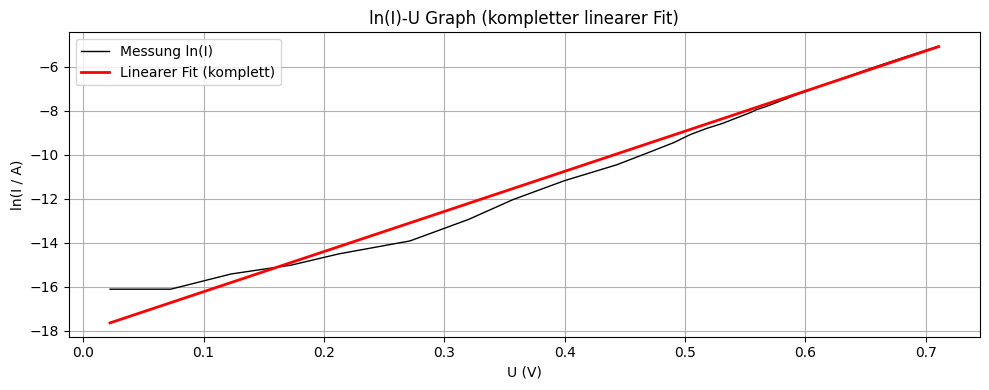

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# CSV einlesen
df1 = pd.read_csv('Messungen/Si_Diode_Aufgabe1.csv')
df1.columns = df1.columns.str.replace('"', '').str.strip()

# Daten (nur Vorwärtsbereich + positive Ströme)
U = df1['U (V)'].to_numpy()
I = df1['I (A)'].to_numpy()
mask = (U > 0) & (I > 0)

U_f = U[mask]
I_f = I[mask]

# sortieren
idx = np.argsort(U_f)
U_f = U_f[idx]
I_f = I_f[idx]

lnI = np.log(I_f)

# ------------------------------------------------------------
# KOMPLETTER FIT in ln(I) = a + m*U  (über alle Vorwärtsdaten)
# ------------------------------------------------------------
m, a = np.polyfit(U_f, lnI, 1)   # ln(I) = m*U + a

# Fitgüte R^2
lnI_hat = m * U_f + a
ss_res = np.sum((lnI - lnI_hat) ** 2)
ss_tot = np.sum((lnI - np.mean(lnI)) ** 2)
r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

# ------------------------------------------------------------
# n aus der Steigung m
# m = 1/(n*UT)  =>  n = 1/(m*UT)
# ------------------------------------------------------------
T_K = 293.15  # ggf. anpassen
kB = 1.380649e-23
e  = 1.602176634e-19
UT = kB * T_K / e
n = 1.0 / (m * UT)

# Ausgabe
#print("=== Komplett-Fit: ln(I) = a + m*U ===")
print(f"m  = {m:.6e} 1/V")
#print(f"a  = {a:.6f}")
#print(f"R² = {r2:.6f}")
#print(f"UT = {UT*1e3:.3f} mV (bei T = {T_K:.2f} K)")
print(f"n  = {n:.4f}")

# Plot: ln(I) vs U + Fitgerade
plt.figure(figsize=(10, 4))
plt.plot(U_f, lnI, label="Messung ln(I)", color="black", linewidth=1)
plt.plot(U_f, lnI_hat, label="Linearer Fit (komplett)", color="red", linewidth=2)
plt.xlabel("U (V)")
plt.ylabel("ln(I / A)")
plt.title("ln(I)-U Graph (kompletter linearer Fit)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


## 2) Z-Diode: Zenerspannung $U_Z$, Gleichstromwiderstand $R$ und differentieller Widerstand $r_d$

### 2.1 Zenerspannung $U_Z$ per Extrapolation
Im Durchbruchbereich (Sperrrichtung) ist die Kennlinie oft näherungsweise linear. Man betrachtet daher $U$ als Funktion von $I$:

$$
U(I)\approx aI+b
$$

Die **Extrapolation auf $I=0$** ergibt:

$$
U_Z = b
$$

### 2.2 Widerstände bei $I = 0.2\,I_{Z,\max}$
Zuerst bestimmt man den maximal gemessenen Zenerstrom $I_{Z,\max}$ und dann:

$$
I_\text{target}=0.2\,I_{Z,\max}
$$

**Gleichstromwiderstand**

$$
R=\frac{U}{I}\quad \text{(am Punkt } I=I_\text{target}\text{)}
$$

**Differentieller Widerstand**

$$
r_d=\frac{dU}{dI}
$$

Praktisch bedeutet das:
- $r_d$ ist die **lokale Steigung** der $U(I)$-Kurve in der Nähe von $I_\text{target}$  
- Man bestimmt $r_d$ typischerweise per lokaler linearer Regression um $I_\text{target}$


=== Z-Diode: Knick über max |d²U/dI²| (links) + Fit ab Knick ===
Knick bei I ≈ 0.010 mA, U ≈ 6.5899 V
R² (Fitbereich) = 0.499080
Uz = 6.713127 V
rd = 9.878252 Ohm
I_target = 1.037640e-03 A (0.2*Iz_max)
R = 6479.489099 Ohm


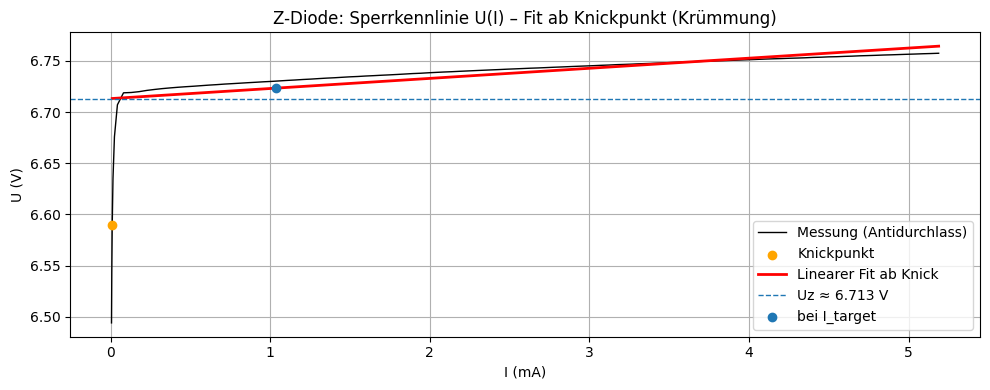

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# CSV einlesen
df_rev = pd.read_csv('Messungen/Z_Diode_Antidurchlass_Aufgabe1_2.csv')
df_rev.columns = df_rev.columns.str.replace('"', '').str.strip()

# Daten
I = df_rev['I (A)'].to_numpy()
U = df_rev['U (V)'].to_numpy()

# sortieren nach I
idx = np.argsort(I)
I = I[idx]
U = U[idx]

# -------------------------
# Glätten (Moving Average)
# -------------------------
def moving_average(y, w=9):
    w = int(w)
    if w < 3:
        return y.copy()
    kernel = np.ones(w) / w
    y_pad = np.pad(y, (w//2, w//2), mode='edge')
    return np.convolve(y_pad, kernel, mode='valid')

U_s = moving_average(U, w=9)

# -------------------------
# Ableitungen
# -------------------------
d1 = np.gradient(U_s, I)      # dU/dI
d2 = np.gradient(d1, I)       # d²U/dI²

# -------------------------
# Knickpunkt: Maximum der |zweiten Ableitung|
# ABER: nur im linken Bereich suchen, sonst "Krümmungsreste" rechts gewinnen.
# z.B. nur bis 25% von I_max
# -------------------------
I_max = np.max(I)
left_mask = I <= 0.25 * I_max

if np.sum(left_mask) < 5:
    left_mask = np.ones_like(I, dtype=bool)  # fallback

kink_idx_local = np.argmax(np.abs(d2[left_mask]))
kink_idx = np.where(left_mask)[0][kink_idx_local]

# optional: nicht den allerersten Punkt nehmen
kink_idx = max(kink_idx, 2)

# -------------------------
# Fit ab Knick: U = a + b*I
# -------------------------
I_fit_data = I[kink_idx:]
U_fit_data = U[kink_idx:]

b, a = np.polyfit(I_fit_data, U_fit_data, 1)
U_hat = b * I_fit_data + a

# R² im Fitbereich
ss_res = np.sum((U_fit_data - U_hat) ** 2)
ss_tot = np.sum((U_fit_data - np.mean(U_fit_data)) ** 2)
r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

Uz = a
rd = b

# R bei I_target = 0.2*Iz_max
Iz_max = np.max(I)
I_target = 0.2 * Iz_max
U_target = a + b * I_target
R = U_target / I_target if I_target != 0 else np.nan

# -------------------------
# Ausgabe
# -------------------------
print("=== Z-Diode: Knick über max |d²U/dI²| (links) + Fit ab Knick ===")
print(f"Knick bei I ≈ {I[kink_idx]*1e3:.3f} mA, U ≈ {U[kink_idx]:.4f} V")
print(f"R² (Fitbereich) = {r2:.6f}")
print(f"Uz = {Uz:.6f} V")
print(f"rd = {rd:.6f} Ohm")
print(f"I_target = {I_target:.6e} A (0.2*Iz_max)")
print(f"R = {R:.6f} Ohm")

# -------------------------
# Plot: U(I) + Fit ab Knick
# -------------------------
plt.figure(figsize=(10, 4))
plt.plot(I*1e3, U, label="Messung (Antidurchlass)", color="black", linewidth=1)
plt.scatter([I[kink_idx]*1e3], [U[kink_idx]], label="Knickpunkt", color="orange", zorder=3)

I_line = np.linspace(I_fit_data.min(), I_fit_data.max(), 200)
U_line = a + b * I_line
plt.plot(I_line*1e3, U_line, label="Linearer Fit ab Knick", color="red", linewidth=2)

plt.axhline(Uz, linestyle="--", linewidth=1, label=f"Uz ≈ {Uz:.3f} V")
plt.scatter([I_target*1e3], [U_target], label="bei I_target", zorder=4)

plt.xlabel("I (mA)")
plt.ylabel("U (V)")
plt.title("Z-Diode: Sperrkennlinie U(I) – Fit ab Knickpunkt (Krümmung)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


## LED

## 3) LED: Schleusenspannung $U_S$ und Wellenlänge $\lambda$

### 3.1 Schleusenspannung $U_S$ aus dem linearen Teil von $I(U)$
Im passenden Bereich kann man die LED-Kennlinie näherungsweise als linear ansetzen:

$$
I \approx mU + b
$$

Die Spannung, bei der der lineare Fit $I=0$ ergibt, ist:

$$
U_S = -\frac{b}{m}
$$

### 3.2 Wellenlänge aus $U_S$
Wenn man annimmt, dass die elektrische Energie pro Ladung ungefähr als Photonenergie abgegeben wird:

$$
eU_S = h\nu
$$

und mit

$$
c=\lambda \nu
$$

folgt

$$
\lambda=\frac{hc}{eU_S}
$$

**Ergebnis**
- $U_S$ aus dem linearen Fit bestimmen  
- $\lambda$ mit $\lambda=\frac{hc}{eU_S}$ berechnen  

---

## 4) Typische Fehlerquellen (kurz)
- **Falscher Fit-Bereich**: außerhalb des linearen Abschnitts (Serienwiderstand, Messgrenzen, Erwärmung)  
- **Zu kleine Ströme**: $-1$-Term ist nicht vernachlässigbar, Rauschen dominiert  
- **Zu große Ströme**: Serienwiderstand verzerrt die Exponentialform  
- **Temperatur**: $U_T=\frac{kT}{e}$ hängt direkt von $T$ ab

=== LED kompletter Fit: I = a + b*U ===
a  = -4.360305e-03 A
b  = 3.684035e-03 A/V
R² = 0.415397
Us = 1.183568 V
lambda = 1047.55 nm


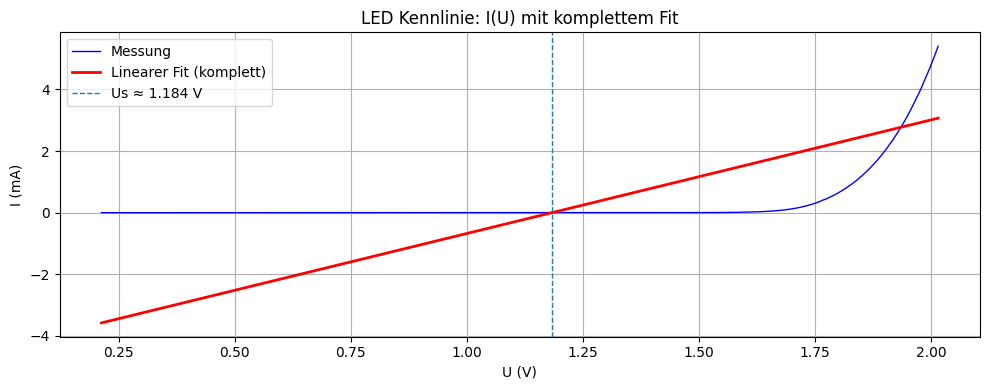

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# =========================
# LED: kompletter Fit I(U) = a + b*U
# -> Us = -a/b
# -> lambda = hc/(e*Us)
# =========================

# Konstanten
E_CHARGE = 1.602176634e-19  # C
H = 6.62607015e-34          # J*s
C0 = 299792458.0            # m/s

# CSV einlesen
df = pd.read_csv('Messungen/Leuchtdiode_Aufgabe1.csv')
df.columns = df.columns.str.replace('"', '').str.strip()

# Daten
U = df['U (V)'].to_numpy()
I = df['I (A)'].to_numpy()

# nur Vorwärtsbereich (positive U und I)
mask = (U > 0) & (I > 0)
U_f = U[mask]
I_f = I[mask]

# sortieren nach U
idx = np.argsort(U_f)
U_f = U_f[idx]
I_f = I_f[idx]

if U_f.size < 2:
    raise ValueError("Zu wenige Vorwärtsdatenpunkte für LED-Fit.")

# -------------------------
# KOMPLETTER Fit: I = a + b*U
# np.polyfit gibt [b, a] zurück
# -------------------------
b, a = np.polyfit(U_f, I_f, 1)  # I = b*U + a
I_hat = b * U_f + a

# R^2
ss_res = np.sum((I_f - I_hat) ** 2)
ss_tot = np.sum((I_f - np.mean(I_f)) ** 2)
r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

# Schleusenspannung
Us = -a / b

# Wellenlänge
lambda_m = (H * C0) / (E_CHARGE * Us)
lambda_nm = lambda_m * 1e9

print("=== LED kompletter Fit: I = a + b*U ===")
print(f"a  = {a:.6e} A")
print(f"b  = {b:.6e} A/V")
print(f"R² = {r2:.6f}")
print(f"Us = {Us:.6f} V")
print(f"lambda = {lambda_nm:.2f} nm")

# Plot
plt.figure(figsize=(10, 4))
plt.plot(U_f, I_f * 1e3, label="Messung", color="blue", linewidth=1)
plt.plot(U_f, I_hat * 1e3, label="Linearer Fit (komplett)", color="red", linewidth=2)
plt.axvline(Us, linestyle="--", linewidth=1, label=f"Us ≈ {Us:.3f} V")
plt.xlabel("U (V)")
plt.ylabel("I (mA)")
plt.title("LED Kennlinie: I(U) mit komplettem Fit")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# Fehlerbetrachtung
